# Let's explore the fish response curves

#### Fish biologists in WI have developed statistical models for fish populations at a given flow for stream segments throughout the state, based on the principle of Ecological Limits of Hydrologic Alteration, or ELOHA. 

##### Essentially their model says "in a stream segment like this one (in this setting, with this type of landscape, and this history of observed flows and stream temperature and fish populations) the probability of this particular species occurring is X. And if you change the flow by Y amount, then that probability of occurrence changes to Z". 

In [1]:
import yaml
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


In [2]:
#### Set the path for the fish response curves
fish_path = Path('../Inputs/fish_curves')


### Let's check out the fish curves 

In [3]:
fishfiles = {i.stem:pd.read_csv(i, index_col=1) for i in fish_path.glob('*.csv')}
fishfiles

{'Brown':             species     SAIFR  Screen  POmodel  POmeasure     PO10R     PO20R  \
 AugQ50                                                                          
 0.0     brown trout  0.044651   False    0.134   0.002100  0.001865  0.001634   
 0.5     brown trout  0.034849   False    0.134   0.003284  0.002813  0.002372   
 1.0     brown trout  0.026772   False    0.134   0.004645  0.003778  0.003120   
 1.5     brown trout  0.022424   False    0.134   0.007985  0.006204  0.004653   
 2.0     brown trout  0.020137   False    0.134   0.011955  0.008987  0.006780   
 2.5     brown trout  0.018235   False    0.134   0.018861  0.013689  0.009346   
 3.0     brown trout  0.018511   False    0.134   0.026782  0.019548  0.013675   
 3.5     brown trout  0.018305   False    0.134   0.036419  0.026471  0.018339   
 4.0     brown trout  0.019551   False    0.134   0.046449  0.034570  0.023973   
 4.5     brown trout  0.021804   False    0.134   0.055088  0.042456  0.030322   
 5.0   

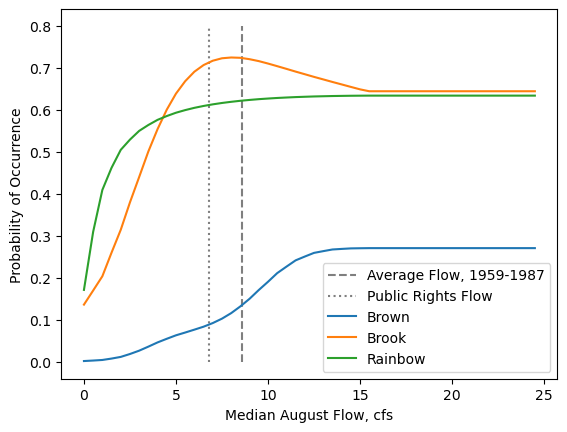

In [4]:
plt.vlines(x=8.6, ymin=0, ymax=0.8, color='black', alpha=.5, label='Average Flow, 1959-1987', linestyles='--')
plt.vlines(x=6.8, ymin=0, ymax=0.8, color='black', alpha=.5, label='Public Rights Flow', linestyles=':')

for fish,cf in fishfiles.items():
    ax = cf['POmeasure'].plot(label=fish)


plt.ylabel('Probability of Occurrence')
plt.xlabel('Median August Flow, cfs')
plt.legend()

### Noting that the historical long-term average is `8.6 CFS`, we can see how much depletion will impact probability of finding a given trout species